# Train quad-hose tracker (L,R,T,B) — folder: quad_hose_tracker


In [1]:
import pickle
import sys
import importlib
from pathlib import Path

import numpy as np
import keras
import matplotlib.pyplot as plt

sys.path.append('../../..')
sys.path.append('/home/wanglab/src/keras-unet-collection')
sys.path.append('/home/wanglab/Programs/tracking/DeepLearningUtils')
sys.path.append('/home/wanglab/Programs/tracking/DeepLearningUtils/src')

from keras_unet_collection import models

import hose_data
importlib.reload(hose_data)
from hose_data import (
    create_hose_augmentation,
    dual_hose_loss,
    get_hose_generator_class,
    KEYPOINT_NAMES,
)

HoseKeypointGenerator = get_hose_generator_class()
print('channels:', KEYPOINT_NAMES)
print('hose_data:', hose_data.__file__)


I0000 00:00:1787685928.986869  123641 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


channels: ('hoseL', 'hoseR', 'hoseT', 'hoseB')
hose_data: /home/wanglab/Programs/tracking/whiskers/whisker_tracking/dual_hose_tracker/hose_data.py


In [ ]:
training_path = Path('/mnt/c/Users/wanglab/Desktop/pico-hose/')
checkpoint_path = 'unet_efficientnet_hose_lrtb_checkpoint.weights.h5'

num_classes = 4  # hoseL, hoseR, hoseT, hoseB
input_shape = (256, 256, 3)
BATCH_SIZE = 16

augmentation = create_hose_augmentation()
pos_weight = 1000.0
channel_weights = (1.0, 1.0, 1.0, 1.0)
exclusivity_weight = 50.0   # L↔R and T↔B pair exclusivity
coactivation_weight = 10.0

freeze_backbone = True
learning_rate = 1e-4

train_pkl = training_path / 'training_data_hose_lrtb.pkl'
test_pkl = training_path / 'testing_data_hose_lrtb.pkl'
print(f'train pkl mtime: {train_pkl.stat().st_mtime}')
print(f'test  pkl mtime: {test_pkl.stat().st_mtime}')


In [3]:
(training_data, training_labels) = pickle.load(open(train_pkl, 'rb'))
(validation_data, validation_labels) = pickle.load(open(test_pkl, 'rb'))

def ensure_nhwc_labels(images, labels):
    labels = np.asarray(labels)
    if labels.ndim != 4:
        raise ValueError(f"Expected 4D labels, got shape {labels.shape}")
    if labels.shape[1:3] == images.shape[1:3]:
        return labels
    if labels.shape[2:4] == images.shape[1:3]:
        return np.moveaxis(labels, 1, -1)
    raise ValueError(f"Cannot align labels {labels.shape} with images {images.shape}")

training_labels = ensure_nhwc_labels(training_data, training_labels)
validation_labels = ensure_nhwc_labels(validation_data, validation_labels)

assert training_labels.shape[-1] == num_classes, training_labels.shape

n_train_labeled = int(np.any(training_labels > 0, axis=(1, 2, 3)).sum())
n_val_labeled = int(np.any(validation_labels > 0, axis=(1, 2, 3)).sum())
print(f"Training: {training_data.shape}, labels {training_labels.shape}")
print(f"Validation: {validation_data.shape}, labels {validation_labels.shape}")
print(f"Train labeled/null: {n_train_labeled}/{len(training_data) - n_train_labeled}")
print(f"Val   labeled/null: {n_val_labeled}/{len(validation_data) - n_val_labeled}")

if training_labels.shape[-1] != 4:
    raise RuntimeError("Expected 4-channel pickles — re-run create_hose_dataset.ipynb")

training_generator = HoseKeypointGenerator(
    training_data, training_labels,
    augmentation=augmentation, batch_size=BATCH_SIZE, training=True,
)
validation_generator = HoseKeypointGenerator(
    validation_data, validation_labels,
    batch_size=BATCH_SIZE, training=False,
)
print(f"Steps/epoch: {len(training_generator)}")


Training: (476, 256, 256, 3), labels (476, 256, 256, 4)
Validation: (120, 256, 256, 3), labels (120, 256, 256, 4)
Train labeled/null: 328/148
Val   labeled/null: 82/38
Steps/epoch: 29


In [4]:
filter_num = [64, 64, 64, 64, 64, 64]

model = models.att_unet_2d(
    input_shape,
    filter_num=filter_num,
    n_labels=num_classes,
    stack_num_down=2,
    stack_num_up=2,
    activation='ReLU',
    atten_activation='ReLU',
    attention='add',
    output_activation='Sigmoid',
    batch_norm=True,
    dropout=True,
    dropout_rate=0.1,
    l2_regularization=False,
    l2_weight=1e-4,
    pool=False,
    unpool=False,
    backbone='EfficientNetB1',
    weights='imagenet',
    freeze_backbone=freeze_backbone,
    freeze_batch_norm=freeze_backbone,
    name='attunet',
)

inputs = keras.Input(shape=input_shape)
x = keras.applications.efficientnet.preprocess_input(inputs)
outputs = model(x)
model = keras.Model(inputs=inputs, outputs=outputs, name='quad_hose_tracker')
model.summary()
print(f"freeze_backbone={freeze_backbone}, trainable_weights={len(model.trainable_weights)}")


I0000 00:00:1787685936.418572  123641 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13360 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:04:00.0, compute capability: 12.0a


Model: "quad_hose_tracker"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attunet_model (Functional)      │ (None, 256, 256, 4)    │     8,579,151 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,579,151 (32.73 MB)

 Trainable params: 2,001,864 (7.64 MB)

 Non-trainable params: 6,577,287 (25.09 MB)

freeze_backbone=True, trainable_weights=79


In [5]:
adamopt = keras.optimizers.AdamW(learning_rate=learning_rate)

model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=str(checkpoint_path),
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
)

early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=20,
    restore_best_weights=True,
)

model.compile(
    optimizer=adamopt,
    loss=lambda y_true, y_pred: dual_hose_loss(
        y_true,
        y_pred,
        pos_weight=pos_weight,
        channel_weights=channel_weights,
        exclusivity_weight=exclusivity_weight,
        coactivation_weight=coactivation_weight,
    ),
    metrics=[],
)


In [6]:
epochs = 150
r = model.fit(
    training_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[model_checkpoint_callback, early_stopping_callback],
)
print(f"Trained {len(r.history['loss'])} epochs")


Epoch 1/150


I0000 00:00:1787685940.426285  123641 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1787685960.859029  123916 service.cc:153] XLA service 0x785df8040c90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787685960.859120  123916 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.8.0; Toolkit: 12.8.0; DNN: 9.10.2)
I0000 00:00:1787685962.186090  123916 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787685966.438801  123916 cuda_dnn.cc:461] Loaded cuDNN version 91002
E0000 00:00:1787685986.138426  123916 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1787686021.864534  123916 device_compiler.h:208] Compiled cluster using 

29/29 ━━━━━━━━━━━━━━━━━━━━ 102s 707ms/step - loss: 0.2845 - val_loss: 0.2563
Epoch 2/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 282ms/step - loss: 0.1920 - val_loss: 0.1054
Epoch 3/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 282ms/step - loss: 0.1541 - val_loss: 0.0854
Epoch 4/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 280ms/step - loss: 0.1426 - val_loss: 0.0718
Epoch 5/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 281ms/step - loss: 0.1263 - val_loss: 0.0599
Epoch 6/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 280ms/step - loss: 0.1154 - val_loss: 0.0573
Epoch 7/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 279ms/step - loss: 0.1103 - val_loss: 0.0517
Epoch 8/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 233ms/step - loss: 0.1073 - val_loss: 0.0594
Epoch 9/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 238ms/step - loss: 0.1011 - val_loss: 0.0546
Epoch 10/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 283ms/step - loss: 0.0970 - val_loss: 0.0421
Epoch 11/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 281ms/step - loss: 0.0910 - val_loss: 0.0397
Epoch 12/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 284ms/st

Val labeled: 82, null: 38


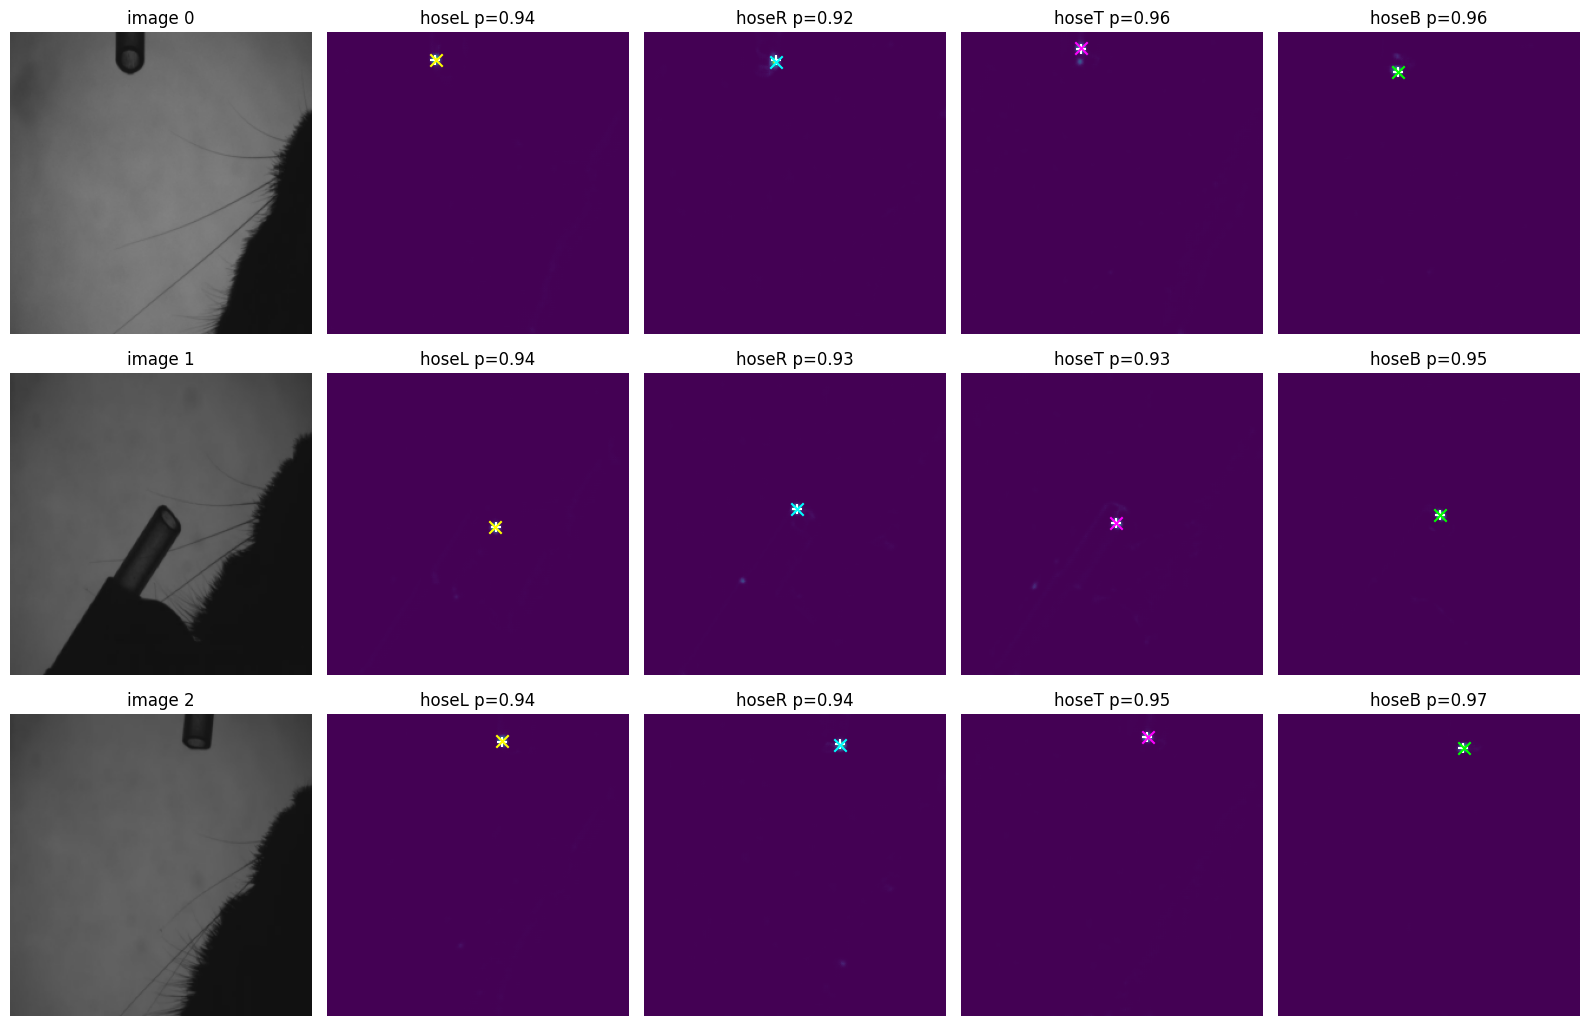

null-frame pred max=0.7659


In [7]:
from hose_data import _extract_exclusive_peaks_multi

has_label = np.any(validation_labels > 0, axis=(1, 2, 3))
labeled_idx = np.where(has_label)[0]
null_idx = np.where(~has_label)[0]
print(f"Val labeled: {len(labeled_idx)}, null: {len(null_idx)}")

show_idx = labeled_idx[:3]
xb = validation_data[show_idx].astype('float32')
yb = validation_labels[show_idx].astype('float32')
if yb.max() > 1.0:
    yb = yb / 255.0
pred = model.predict(xb, verbose=0)

names = list(KEYPOINT_NAMES)
colors = ['yellow', 'cyan', 'magenta', 'lime']
fig, axes = plt.subplots(len(show_idx), 5, figsize=(16, 3.5 * len(show_idx)))
if len(show_idx) == 1:
    axes = np.expand_dims(axes, 0)

for i in range(len(show_idx)):
    axes[i, 0].imshow(validation_data[show_idx[i]][..., ::-1])
    axes[i, 0].set_title(f'image {show_idx[i]}')
    axes[i, 0].axis('off')
    peaks = _extract_exclusive_peaks_multi(pred[i])
    for c in range(4):
        ax = axes[i, c + 1]
        ax.imshow(pred[i, ..., c], vmin=0, vmax=max(0.1, float(pred[i, ..., c].max())))
        gy, gx = np.unravel_index(int(np.argmax(yb[i, ..., c])), yb.shape[1:3])
        ax.scatter(gx, gy, c='white', marker='+', s=60)
        ax.scatter(peaks[c].y, peaks[c].x, c=colors[c], marker='x', s=80)
        ax.set_title(f'{names[c]} p={peaks[c].prob:.2f}')
        ax.axis('off')
plt.tight_layout()
plt.show()

if len(null_idx) > 0:
    pn = model.predict(validation_data[null_idx[:4]].astype('float32'), verbose=0)
    print(f"null-frame pred max={pn.max():.4f}")
